##### Instructions
- Keep the original structure, you may add additional code cells and/or mark-down cells for clarity, legibility and/or structure.
- Add the required descriptions, explanations, justifications to the mark-down cells.

# EXAM03: Data Science Group Assignment - Iteration 3

**Group name:** [Enter Group Number]

**Student names & numbers:**
* Scott Mulder - 101232
* Sidney Felius - [Student no.]
* Valentijn van Grunsven - [Student no.]

---

## 0. Iteration setup

**Import libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (mean_absolute_error, mean_squared_error, 
                             r2_score, accuracy_score, confusion_matrix)

**Load & Merge dataset(s)**

In [3]:

df_iter2 = pd.read_csv('data/ship_inspections_iter2.csv')
df_iter3 = pd.read_csv('data/ship_performance_logs_iter3.csv')

# Merge the datasets on Ship_ID
df_merged = df_iter2.merge(df_iter3, on='Ship_ID', how='left')

print(f"Iteration 2 dataset shape: {df_iter2.shape}")
print(f"Iteration 3 dataset shape: {df_iter3.shape}")
print(f"Merged dataset shape: {df_merged.shape}")
print(f"\nMerged dataset columns:\n{df_merged.columns.tolist()}")

Iteration 2 dataset shape: (368315, 5)
Iteration 3 dataset shape: (361069, 3)
Merged dataset shape: (368315, 7)

Merged dataset columns:
['Ship_ID', 'Hull_Integrity', 'Reactor_Power', 'Propulsion_Type', 'Ship_Class', 'Lightyears_Traveled', 'Registration_Status']


---

## 1. Business Understanding

**Situation description**

*Describe the final problem. Why is Nebula Brokerage moving from the simple models (iterations 1 and 2) to a machine learning approach?*

**Business objective(s)**

*Justify why an AI-driven pipeline (predicting both Galactic Credits and Condition) adds business value.*

**Data mining goal(s)**

*Explain the two modeling tasks for this iteration.*

**Success criteria**

*Determine the success criteria.*

---

## 2. Data Understanding

**Data exploration (New Features)**

*Show the summary statistics for the newly merged data. Focus your description on the new variables: Lightyears_Traveled and Registration_Status.*

In [9]:
print("First five rows of the dataset:")
display(df_merged.head(5))

print("Dataset Information:")
df_merged.info()

print("Description of the dataset:")
df_merged.describe(include=['object'])

First five rows of the dataset:


,Ship_ID,Hull_Integrity,Reactor_Power,Propulsion_Type,Ship_Class,Lightyears_Traveled,Registration_Status
0,7316814884,Operational,80.0,Ion Drive,Hauler,40.610676,Refurbished
1,7316814758,Operational,80.0,Hyperdrive,Hauler,66.153551,Imperial Certified
2,7316814989,Pristine,80.0,Hyperdrive,Hauler,10.844388,Refurbished
3,7316743432,Pristine,80.0,Plasma Thruster,Hauler,29.576094,Refurbished
4,7316356412,Operational,60.0,Ion Drive,Freighter,122.111671,Refurbished


Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 368315 entries, 0 to 368314
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Ship_ID              368315 non-null  int64  
 1   Hull_Integrity       368315 non-null  str    
 2   Reactor_Power        338877 non-null  float64
 3   Propulsion_Type      311705 non-null  str    
 4   Ship_Class           368315 non-null  str    
 5   Lightyears_Traveled  361069 non-null  float64
 6   Registration_Status  361069 non-null  str    
dtypes: float64(2), int64(1), str(4)
memory usage: 19.7 MB
Description of the dataset:


C:\Users\sidne\AppData\Local\Temp\ipykernel_37584\1998131396.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_merged.describe(include=['object'])


,Hull_Integrity,Propulsion_Type,Ship_Class,Registration_Status
count,368315,311705,368315,361069
unique,3,8,8,6
top,Operational,Ion Drive,Shuttle,Imperial Certified
freq,141273,177374,125707,175316


**Visualizations and patterns**
*Create visualizations to discover the impact of the new features.

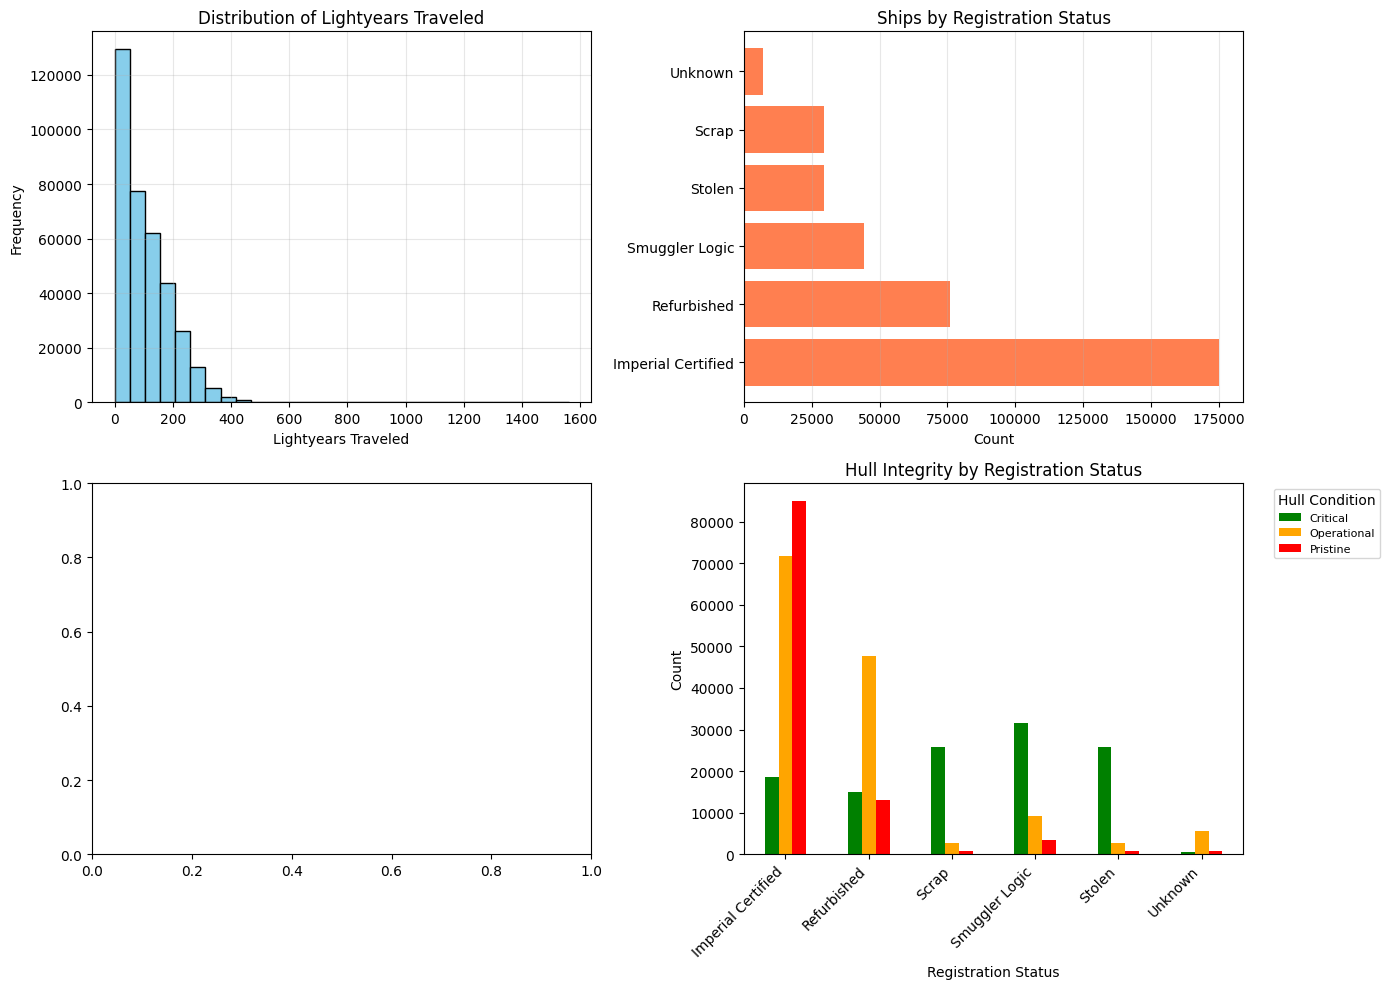

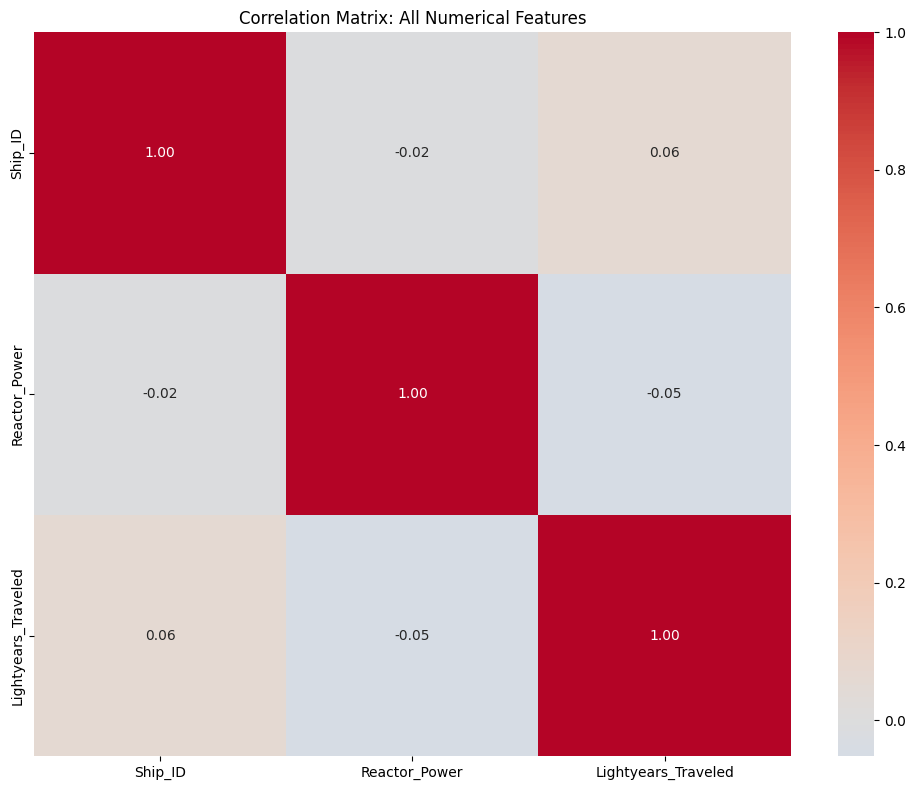

In [8]:
# Create visualizations for the new features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribution of Lightyears_Traveled
ax1 = axes[0, 0]
if 'Lightyears_Traveled' in df_merged.columns:
    ax1.hist(df_merged['Lightyears_Traveled'], bins=30, color='skyblue', edgecolor='black')
    ax1.set_xlabel('Lightyears Traveled')
    ax1.set_ylabel('Frequency')
    ax1.set_title('Distribution of Lightyears Traveled')
    ax1.grid(alpha=0.3)

# 2. Registration Status Distribution
ax2 = axes[0, 1]
if 'Registration_Status' in df_merged.columns:
    status_counts = df_merged['Registration_Status'].value_counts()
    ax2.barh(status_counts.index, status_counts.values, color='coral')
    ax2.set_xlabel('Count')
    ax2.set_title('Ships by Registration Status')
    ax2.grid(alpha=0.3, axis='x')

# 3. Lightyears_Traveled vs Galactic_Credits
ax3 = axes[1, 0]
if 'Lightyears_Traveled' in df_merged.columns and 'Galactic_Credits' in df_merged.columns:
    ax3.scatter(df_merged['Lightyears_Traveled'], df_merged['Galactic_Credits'], 
                alpha=0.5, color='steelblue')
    ax3.set_xlabel('Lightyears Traveled')
    ax3.set_ylabel('Galactic Credits')
    ax3.set_title('Relationship: Mileage vs Price')
    ax3.grid(alpha=0.3)

# 4. Hull Integrity distribution by Registration Status (using count plot)
ax4 = axes[1, 1]
if 'Registration_Status' in df_merged.columns and 'Hull_Integrity' in df_merged.columns:
    cross_tab = pd.crosstab(df_merged['Registration_Status'], df_merged['Hull_Integrity'])
    cross_tab.plot(kind='bar', ax=ax4, color=['green', 'orange', 'red', 'gray'][:len(cross_tab.columns)])
    ax4.set_xlabel('Registration Status')
    ax4.set_ylabel('Count')
    ax4.set_title('Hull Integrity by Registration Status')
    ax4.legend(title='Hull Condition', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.sca(ax4)
    plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Additional correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
numerical_cols = df_merged.select_dtypes(include=[np.number]).columns
correlation_matrix = df_merged[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Matrix: All Numerical Features')
plt.tight_layout()
plt.show()

**Data insights and data quality**

* **Insights:** Does high mileage lower the price? Does a 'Stolen' status correlate with critical hull condition?
* **Quality issues:** Document any missing values and other issues

---

## 3. Data Preparation

**Cleaning and preprocessing**

*Describe and justify how you resolve your data errors.*

In [1]:
# CODE CELL: Data cleaning, preprocessing

**Feature encoding**

*Describe how you converted your categorical columns into a format the model can use.*

In [2]:
# CODE CELL: Apply feature ecoding and define your features (X)

---

## 4. Modeling: Task A

**Regression setup**

*Set up a [Linear Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) model to predict `Galactic_Credits`. Make sure to split your data into training and testing sets.*

In [3]:
# CODE CELL: Train-Test split & train the Linear Regression model

**Testing and performance (Regression)**

*Calculate the MAE, RMSE and R2 score. Create a plot showing Actual vs. Predicted prices to visually verify model performance.*

In [4]:
# CODE CELL: Evaluate the rgression model and plot Actual vs Predicted

---

## 5. Modeling: Task B

**Classification setup**

*Set up a [Decision Tree Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) to predict `Hull_Integrity`. Split the data into training and testing sets.*

In [7]:
# CODE CELL: Train-Test split & train the Decision Tree model.

**Testing and performance (classification)**

*Calculate the Accuracy and plot a confusion matrix. Explain what the matrix tells you about the predictions.*

In [6]:
# CODE CELL: Evaluate your classification model (check ou tthe metrics, include a confusion matrix)

---

## 6. Evaluation

**Assessment against success criteria** 

*Compare your models to the baselines:*
* *Are thr scores of this regression model better than Iteration 1? Why?*
* *Are the scores of the decision tree better than your manual rules from Iteration 2? Why?*

**Key findings and limitations**

*What are the final conclusions? Should Nebula Brokerage deploy these models? What are the remaining limitations?*

Use [pandas' to_csv](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html) to export your cleaned and merged dataset.

---

## 7. Personal Contribution

| Student name | Contribution | Personal lessons learned |
| :--- | :--- | :--- |
| Student name 1 | *Contribution description* | *Personal lessons learned this iteration* |
| Student name 2 | *Contribution description* | *Personal lessons learned this iteration* |
| Student name 3 | *Contribution description* | *Personal lessons learned this iteration* |